# Hyperparameter Tuning + Regularization — Practical Reference

## Topics
- Parameters vs Hyperparameters
- Regularization
- Regularization and overfitting
- Bias-variance connection
- L1, L2, Elastic Net
- Regularization across different ML models
- Logistic Regression and `C`
- Cross Validation
- Hyperparameter Tuning
- GridSearchCV
- Randomized Search

## Parameters vs Hyperparameters

**Parameters** are learned by the model during training.

For Linear Regression:
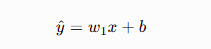

`w1` and `b` are parameters.

**Hyperparameters** are settings chosen externally.

| Model | Example hyperparameters |
|---|---|
| Logistic Regression | `C`, `penalty`, `solver`, `max_iter` |
| Decision Tree | `max_depth`, `min_samples_split`, `min_samples_leaf` |
| Random Forest | `n_estimators`, `max_depth`, `max_features` |
| KNN | `n_neighbors` |
| Neural Network | learning rate, batch size, layers |

**Rule:** Parameter → model learns it. Hyperparameter → we choose it.

## Regularization

Imagine a student who memorizes the exact questions in a practice set instead of understanding the concepts. The student performs very well on those exact questions but struggles with new questions.

That is similar to **overfitting**.

Regularization is like telling the model:

> **“Fit the data well, but don't become unnecessarily complicated.”**

Regularization is a technique used to **control model complexity** and help reduce overfitting.

## Regularization and Model Complexity


```text
Too Simple
    ↓
Underfitting
```
---

```text
Appropriate Complexity
    ↓
Good Generalization
```
---
```text
Too Complex
    ↓
Overfitting
```

Regularization helps control complexity.

- Too little regularization → more freedom → potentially higher overfitting risk.
- Too much regularization → model may become too constrained → potentially higher underfitting risk.

The goal is an appropriate amount of regularization.

## Regularization and Bias-Variance

```text
Strong regularization
        ↓
More constrained model
        ↓
Can increase bias
        ↓
Possible underfitting
```

```text
Weak regularization
        ↓
More freedom
        ↓
Can increase variance
        ↓
Possible overfitting
```

Therefore, regularization is one way to manage the **bias-variance trade-off**.

## Regularization Is a Technique — Not a Parameter

Regularization is a **technique/concept** used to control model complexity.

The settings that control regularization are often **hyperparameters**.

For Logistic Regression:

```text
Regularization
      ↓
C
```

Here:
- Regularization → technique
- `C` → hyperparameter
- Model weights/coefficient values → parameters

Not every hyperparameter is related to regularization. For example, `solver` and `max_iter` are also hyperparameters but serve different purposes.

## Regularization Techniques Across Models

| Model | Common complexity-control / regularization techniques |
|---|---|
| Linear Regression | Ridge, Lasso, Elastic Net |
| Logistic Regression | L1, L2, Elastic Net |
| Decision Tree | `max_depth`, `min_samples_leaf`, `max_leaf_nodes` |
| Random Forest | Bootstrap sampling, random feature selection, tree constraints |
| Gradient Boosting | Learning rate, number of trees, tree depth, subsampling |
| SVM | `C`, margin-related regularization |
| KNN | `k` controls smoothness/complexity |
| Neural Network | L1, L2, Dropout, Early Stopping, Data Augmentation |

Different models control complexity in different ways.

## Penalty Based

### L1 Regularization — Lasso

L1 adds a penalty based on the absolute values of coefficients:


> L1 can make some coefficients exactly zero.

Therefore L1 can also perform **feature selection**.

Common example: **Lasso Regression**.

### L2 Regularization — Ridge

L2 adds a penalty based on squared coefficients:

Important property:

> L2 generally shrinks coefficients toward zero but does not usually make many exactly zero.

Common example: **Ridge Regression**.

### Elastic Net

Elastic Net combines L1 and L2:

Conceptually:

```text
L1 → can make coefficients zero
L2 → shrinks coefficients
Elastic Net → combines both

## Regularization Strength

### The `C` Hyperparameter

In scikit-learn Logistic Regression:

> **`C` controls the inverse of regularization strength.**

| `C` | Regularization |
|---:|---|
| Small `C` | Stronger regularization |
| Large `C` | Weaker regularization |

So:

```text
C ↓ → regularization strength ↑ → more restriction
C ↑ → regularization strength ↓ → more freedom
```

The suitable value depends on the dataset and is selected using validation/CV.

### Why Hyperparameter Tuning?

Suppose:

```text
C = 0.01
C = 0.1
C = 1
C = 10
C = 100
```

Which should we use?

We systematically test candidates:

```text
Try different C values
       ↓
Cross Validation
       ↓
Compare validation performance
       ↓
Select suitable C
```

This is **Hyperparameter Tuning**.

## GridSearchCV

`GridSearchCV` automates hyperparameter search and cross-validation.

```python
GridSearchCV(
    estimator=model,
    param_grid=parameter_values,
    cv=5,
    scoring="accuracy"
)
```

If there are 5 `C` values and 5 folds:

```text
5 combinations × 5 folds = 25 model fits
```

# Practical Example — Logistic Regression

Workflow:

```text
Load dataset
↓
Train-test split
↓
Feature scaling
↓
Baseline Logistic Regression
↓
Evaluate baseline
↓
GridSearchCV + 5-fold CV
↓
Find best C
↓
Evaluate tuned model on test data
```

In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

## Data Loading

In [3]:
data = load_breast_cancer()
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [4]:
X = data['data']
y = data['target']

In [5]:
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [6]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

## Train Test Split

In [7]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Feature Scaling

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = LogisticRegression()
model.fit(X_train,y_train)
model.score(X_train,y_train)

0.9868131868131869

## Manual Hyperparameter Tuning

In [10]:
model = LogisticRegression(C=0.1)
model.fit(X_train,y_train)
model.score(X_train,y_train)

0.9802197802197802

In [11]:
c_value = [0.01,0.1,1,10,100]
penalty = ['l1','l2']

for i in c_value:
    model = LogisticRegression(C=i)
    model.fit(X_train,y_train)
    print("Train Score for value: ",i,"is :",model.score(X_train,y_train))
    print("Test Score for value: ",i,"is :",model.score(X_test,y_test))
    print("*"*50)

Train Score for value:  0.01 is : 0.9560439560439561
Test Score for value:  0.01 is : 0.9649122807017544
**************************************************
Train Score for value:  0.1 is : 0.9802197802197802
Test Score for value:  0.1 is : 0.9824561403508771
**************************************************
Train Score for value:  1 is : 0.9868131868131869
Test Score for value:  1 is : 0.9736842105263158
**************************************************
Train Score for value:  10 is : 0.989010989010989
Test Score for value:  10 is : 0.9736842105263158
**************************************************
Train Score for value:  100 is : 0.9934065934065934
Test Score for value:  100 is : 0.9385964912280702
**************************************************


## What if there are more than 1 hyperparameter

In [12]:
c_value = [0.01,0.1,1,10,100]
penalty = ['l1','l2']

for i,j in zip(c_value,penalty):
  print(i,j)

0.01 l1
0.1 l2


## Define Hyperparameteres

In [13]:
param_grid = {
    'C': [0.001,0.01, 0.1, 1, 10, 100,1000],
    'penalty': ['l1', 'l2']
}

## Grid Search - Hyperparameter tuning

In [14]:
model = LogisticRegression(solver='liblinear')

In [15]:
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(solver='liblinear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2']},
             scoring='accuracy')

### **Best Parameters**

In [16]:
grid_search.best_params_

{'C': 0.1, 'penalty': 'l2'}

### **Best mean CV Scores**

In [17]:
grid_search.best_score_

np.float64(0.9780219780219781)

### Manually Initializing Best Model

In [18]:
model = LogisticRegression(C=0.1,penalty='l2',solver='liblinear')
model.fit(X_train,y_train)

LogisticRegression(C=0.1, solver='liblinear')

In [19]:
y_predict = model.predict(X_test)

In [20]:
y_predict

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

### Auto initializing using Gridsearch Best_estimator_

In [21]:
best_model = grid_search.best_estimator_
print(best_model)

LogisticRegression(C=0.1, solver='liblinear')


## Random Search - Hyperparameter Tuning

In [22]:
model = LogisticRegression(solver='liblinear')
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=5,
    cv=5,
    scoring="accuracy",
    random_state=42
)

In [23]:
random_search

RandomizedSearchCV(cv=5, estimator=LogisticRegression(solver='liblinear'),
                   n_iter=5,
                   param_distributions={'C': [0.001, 0.01, 0.1, 1, 10, 100,
                                              1000],
                                        'penalty': ['l1', 'l2']},
                   random_state=42, scoring='accuracy')

In [24]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(solver='liblinear'),
                   n_iter=5,
                   param_distributions={'C': [0.001, 0.01, 0.1, 1, 10, 100,
                                              1000],
                                        'penalty': ['l1', 'l2']},
                   random_state=42, scoring='accuracy')

### Best Parameter

In [25]:
random_search.best_params_

{'penalty': 'l2', 'C': 0.1}

### Best Score

In [28]:
random_search.best_score_

np.float64(0.9780219780219781)

### Best Model/Estimator

In [27]:
random_search.best_estimator_

LogisticRegression(C=0.1, solver='liblinear')

In [29]:
best_model = random_search.best_estimator_
best_model.fit(X_train, y_train)

LogisticRegression(C=0.1, solver='liblinear')

In [30]:
best_model.predict(X_test)

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [32]:
#pickle
import pickle

In [33]:
with open('model.pkl','wb') as file:
  pickle.dump(best_model,file)

In [34]:
with open('model.pkl','rb') as file:
  log_model = pickle.load(file)

In [35]:
log_model.predict(X_test)

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])